In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
hr = pd.read_csv('../data/interim/heartrate_seconds_merged.csv')
hr['Time'] = pd.to_datetime(hr['Time'])
hr['Date'] = hr['Time'].dt.normalize()

daily_hr = hr.groupby(['Id','Date'])['Value'].mean().reset_index().rename(columns={'Value':'AvgHR'})

daily = pd.read_csv('../data/processed/daily_features.csv', parse_dates=['ActivityDate'])
merged = daily.merge(daily_hr, left_on=['Id','ActivityDate'], right_on=['Id','Date'], how='inner')
merged = merged[merged['is_worn']]

print('심박+활동 매칭된 사용자-일 수:', len(merged), '/ 심박 보유 사용자:', merged['Id'].nunique())

심박+활동 매칭된 사용자-일 수: 475 / 심박 보유 사용자: 15


In [3]:
daily_hr = hr.groupby(['Id','Date'])['Value'].mean().reset_index().rename(columns={'Value':'AvgHR'})

In [4]:
daily = pd.read_csv('../data/processed/daily_features.csv', parse_dates=['ActivityDate'])
merged = daily.merge(daily_hr, left_on=['Id','ActivityDate'], right_on=['Id','Date'], how='inner')
merged = merged[merged['is_worn']]

print('심박+활동 매칭된 사용자-일 수:', len(merged), '/ 심박 보유 사용자:', merged['Id'].nunique())

심박+활동 매칭된 사용자-일 수: 475 / 심박 보유 사용자: 15


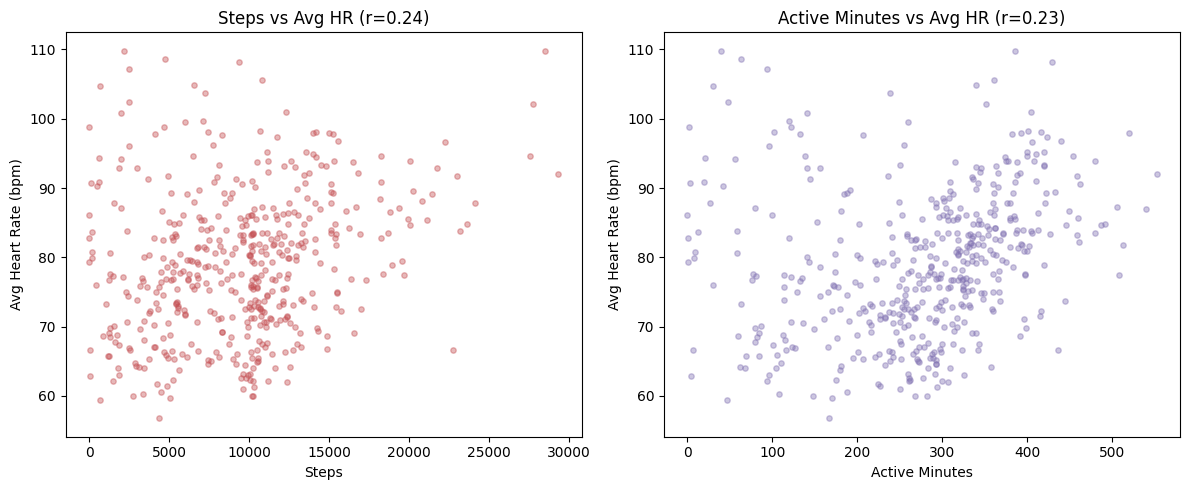

r(steps,HR)= 0.238  r(activemin,HR)= 0.229


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(merged['TotalSteps'], merged['AvgHR'], alpha=0.4, s=15, color='#C44E52')
r = merged['TotalSteps'].corr(merged['AvgHR'])
axes[0].set_title(f'Steps vs Avg HR (r={r:.2f})')
axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Avg Heart Rate (bpm)')

axes[1].scatter(merged['ActiveMinutes'], merged['AvgHR'], alpha=0.4, s=15, color='#8172B2')
r2 = merged['ActiveMinutes'].corr(merged['AvgHR'])
axes[1].set_title(f'Active Minutes vs Avg HR (r={r2:.2f})')
axes[1].set_xlabel('Active Minutes'); axes[1].set_ylabel('Avg Heart Rate (bpm)')

plt.tight_layout()
plt.savefig('../outputs/figures/03_heartrate.png', dpi=130)
plt.show()
print('r(steps,HR)=', round(r,3), ' r(activemin,HR)=', round(r2,3))

In [6]:
user_hr = merged.groupby('Id').agg(AvgHR=('AvgHR','mean'), HRStd=('AvgHR','std'), AvgCal=('Calories','mean'))
print('user-level r(AvgHR, AvgCal):', round(user_hr['AvgHR'].corr(user_hr['AvgCal']), 3))
print('user-level r(HRStd(안정성), AvgCal):', round(user_hr['HRStd'].corr(user_hr['AvgCal']), 3))
user_hr.round(1)

user-level r(AvgHR, AvgCal): -0.094
user-level r(HRStd(안정성), AvgCal): -0.139


,AvgHR,HRStd,AvgCal
Id,,,
2022484408,80.4,4.4,2500.3
2026352035,83.3,15.9,1517.2
2347167796,76.7,6.6,2033.4
4020332650,85.4,8.0,2829.4
4388161847,66.1,5.1,3098.5
4558609924,81.0,6.3,1976.6
5553957443,68.0,4.7,1855.3
5577150313,67.7,4.4,3421.9
6117666160,84.0,5.0,2429.9
